In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [18]:
root_path = "/home/stefan/ioai-prep/kits/ojia-2026/asteroizi"
seed = 333

# !cat {root_path}/starter_kit.py
!ls {root_path}

custom_archive	    sample_output.csv  test_data.csv	       train_data.csv
custom_archive.zip  submission.csv     train_data_cleaned.csv


# Cleaning

In [37]:
!head -n 15 {root_path}/train_data.csv

datapointID,X,Y,Z,Class
11.-92734-7-5153-9845.59462205.50379-.062544069
2133109-8-.23252-
3-39.690811899155420-1565043411407
4,-0.8758377969718945,-0.1337808157622999,-0.2543177818618487,0
5,0.4764644709005536,0.5671207729005672,-0.5870279826780991,0
6..-439-6178191.
75562237.9114.08.214785..87-1494169-111542-648-02128209-801
8260469903734837895152614-96777952748633-98..556
9-377133137596750
10,-0.6729028316565682,-0.8326197638445081,-0.8069070857512739,0
114-5652808609.980-12-47861969521155-52328
129.175-2575033477867794334.9140.1-89.8577363663507.9916
13942977244394559338-9052467721-214256612444.90645451189491853-112-342073-22960364
14232874636774383-.27488.35.99771161--1194169.5029421365-6.6-21506838095337-124658533.68449--7


In [38]:
pd.read_csv(f"{root_path}/train_data.csv")

,datapointID,X,Y,Z,Class
0,11.-92734-7-5153-9845.59462205.50379-.062544069,NaN,NaN,NaN,NaN
1,2133109-8-.23252-,NaN,NaN,NaN,NaN
2,3-39.690811899155420-1565043411407,NaN,NaN,NaN,NaN
3,4,-0.875838,-0.133781,-0.254318,0.0
4,5,0.476464,0.567121,-0.587028,0.0
...,...,...,...,...,...
11275,11276637454076552-3883936.3301.53,NaN,NaN,NaN,NaN
11276,11277009472302414801873219397.11,NaN,NaN,NaN,NaN
11277,112783.87700-94056-007-2.75-583362.2.76478007,NaN,NaN,NaN,NaN
11278,11279748392849.765046.38.1618445904,NaN,NaN,NaN,NaN


In [ ]:
with open(f"{root_path}/train_data.csv", "r") as f:
    lines = f.readlines()

    good_lines = [l for l in lines if l.count(',')]
    good_data = ''.join(good_lines)

with open(f"{root_path}/train_data_cleaned.csv", "w") as f:
    f.write(good_data)

In [21]:
df = pd.read_csv(f"{root_path}/train_data_cleaned.csv")
df.head()

,datapointID,X,Y,Z,Class
0,4,-0.875838,-0.133781,-0.254318,0
1,5,0.476464,0.567121,-0.587028,0
2,10,-0.672903,-0.832620,-0.806907,0
3,22,-0.179485,0.434237,-0.540987,0
4,30,0.732729,0.165628,0.489996,1


# Subtask 1

In [22]:
subtask1 = df["Class"]

# Subtask 2

## Data

In [23]:
df_test = pd.read_csv(f"{root_path}/test_data.csv")

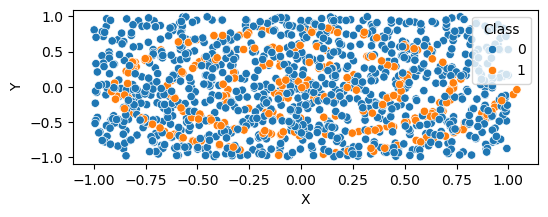

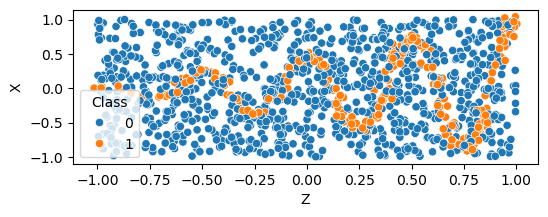

In [24]:
plt.figure(figsize=(12 // 2, 4 // 2))
sns.scatterplot(x="X", y="Y", data=df, hue="Class")
plt.show()

plt.figure(figsize=(12 // 2, 4 // 2))
sns.scatterplot(x="Z", y="X", data=df, hue="Class")
plt.show()

In [25]:
def prep_df(df: pd.DataFrame):
    df = df.drop(["datapointID", "Class"], errors='ignore', axis=1)
    return df

<Axes: xlabel='Class', ylabel='Count'>

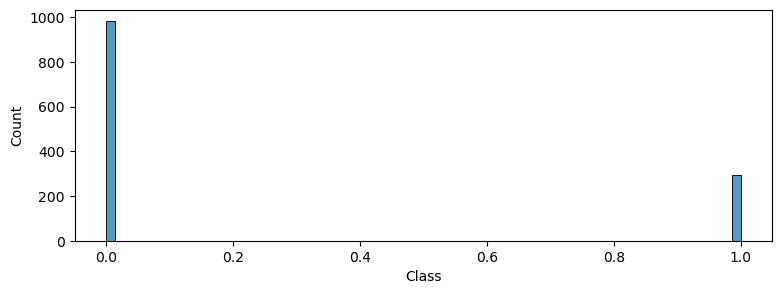

In [26]:
df_train = prep_df(df)

plt.figure(figsize=(9,3))
sns.histplot(df["Class"])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(df_train, df["Class"], test_size=0.2, stratify=df["Class"], random_state=seed)

## Model

In [ ]:
def evaluate(clf):
    cv = cross_val_score(clf, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    cv = cv.mean() - cv.std()

    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    return cv.item(), f1_score(y_test, preds, pos_label=1)

In [29]:
lr = LogisticRegression()

evaluate(lr)

(0.0, 0.0)

In [51]:
svc = SVC(class_weight="balanced", random_state=seed)

evaluate(svc)

(0.5303365271618955, 0.5728155339805825)

In [53]:
svc = SVC(gamma=100, class_weight="balanced", random_state=seed)

evaluate(svc)

(0.8409794914589702, 0.8360655737704918)

In [32]:
test_feats = prep_df(df_test)
subtask2 = svc.predict(test_feats)

# Submission

In [33]:
def build_sub(sid, ans):
    return pd.DataFrame({
        "datapointID": (df_test if sid == 2 else df)["datapointID"],
        "subtaskID": sid,
        "answer": ans
    })

subtasks = [
    (1, subtask1),
    (2, subtask2)
]

submission = pd.concat([build_sub(sid, ans) for sid, ans in subtasks])

In [34]:
submission.head()

,datapointID,subtaskID,answer
0,4,1,0
1,5,1,0
2,10,1,0
3,22,1,0
4,30,1,1


In [35]:
submission.to_csv(f"{root_path}/submission.csv", index=False)